In [32]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gazizovvyacheslav/user-sessions-with-target/user_sessions_with_target.csv


# Генераия признаков


Для генерации признаков используются:
1. user_sessions_with_target.csv - таблица сессий
2. events.csv - источник всех событий внутри сессии
3. installations.csv - источник информации об установке и трафике

Сначала прочитаем user_sessions_with_target.csv и посмотрим какие признаки оттуда можно сделать

## Часть 1

past_sessions_count - количество сессий до текущей

past_last_session_duration_sec - длительность последней сессии

avg_past_session_duration_sec - средняя длительность прошлых сессий

avg_past_5_sessions_duration_sec - средняя длительность по прошлым 5 сессиям

median_past_session_duration_sec - медианная длительность прошлых сессий

total_past_time_sec - суммарное время в прошлых сессиях

avarage_pause_sec - средняя длительность пауз между сессиями

last_pause_sec - время с последней сесс

active_days_count - сколько дней пользователь был активен раньше

total_past_events_count - сколько событий было в прошлых сессиях

avg_past_events_count - среднее число событий в прошлых сессиях

max_past_session_duration_sec - максимальная длительность прошлых сессий

min_past_session_duration_sec - минимальная длительность прошлых сессий

last_5_total_duration_sec - суммарная длительность последних 5 прошлых сессий

sessions_per_active_day - среднее число сессий на активный день

session_hour - час начала текущей сессии

session_dayofweek - день недели текущей сессии

is_weekend - началась ли сессия в выходной

last_session_events_count - количество событий в предыдущей сессии

avg_past_5_events_count - среднее число событий за последние 5 прошлых сессий


In [33]:
import pandas as pd


sessions_path = "/kaggle/input/datasets/gazizovvyacheslav/user-sessions-with-target/user_sessions_with_target.csv"
sessions = pd.read_csv(sessions_path)
print(sessions.head(3))
print()
print("Размеры :", sessions.shape)
print()
print(sessions.columns)
print()
print(sessions.info())


   appmetrica_device_id                   installation_id   session_id  \
0   1219361434347362249  d7222de1105c40159efdf16a07bc2080  10000000013   
1  12768366038869339700  1a284947f3484798a3d3548689fa35d3  10000000085   
2    138580996056989852  d5828d05106a4a51839c585dd22216e3  10000000015   

                 start                  end  duration_seconds duration_hms  \
0  2025-10-31 23:00:00  2025-10-31 23:13:56               836     00:13:56   
1  2025-10-31 23:00:00  2025-10-31 23:01:39                99     00:01:39   
2  2025-10-31 23:00:00  2025-10-31 23:37:48              2268     00:37:48   

   events_count  target_next_session_length_sec  
0           200                           222.0  
1            15                            32.0  
2           280                             NaN  

Размеры : (4153829, 9)

Index(['appmetrica_device_id', 'installation_id', 'session_id', 'start', 'end',
       'duration_seconds', 'duration_hms', 'events_count',
       'target_next_sessio

In [34]:
sessions["start"] = pd.to_datetime(sessions["start"])
sessions["end"] = pd.to_datetime(sessions["end"])


sessions = sessions.sort_values(["appmetrica_device_id", "start"]).reset_index(drop=True)
display(sessions.head(3))

,appmetrica_device_id,installation_id,session_id,start,end,duration_seconds,duration_hms,events_count,target_next_session_length_sec
0,11356303176276,69a93a4f8ada47f58caef1024c8fe1ca,10000000001,2026-02-01 00:47:08,2026-02-01 00:47:11,3,00:00:03,64,NaN
1,23934645582152,a8950b8e026a4f1d971615f7db5e641d,10000000002,2026-04-05 23:20:27,2026-04-05 23:20:28,1,00:00:01,26,3.0
2,23934645582152,a8950b8e026a4f1d971615f7db5e641d,10000000003,2026-04-05 23:22:42,2026-04-05 23:22:45,3,00:00:03,163,NaN


In [35]:
g = sessions.groupby("appmetrica_device_id", group_keys=False)

sessions["past_sessions_count"] = g.cumcount()
sessions["past_last_session_duration_sec"] = g["duration_seconds"].shift(1)

sessions["avg_past_session_duration_sec"] = g["duration_seconds"].transform(
    lambda x: x.shift(1).expanding().mean()
)

sessions["avg_past_5_sessions_duration_sec"] = g["duration_seconds"].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

sessions["median_past_session_duration_sec"] = g["duration_seconds"].transform(
    lambda x: x.shift(1).expanding().median()
)

sessions["total_past_time_sec"] = g["duration_seconds"].transform(
    lambda x: x.shift(1).expanding().sum()
)

sessions["max_past_session_duration_sec"] = g["duration_seconds"].transform(
    lambda x: x.shift(1).expanding().max()
)

sessions["min_past_session_duration_sec"] = g["duration_seconds"].transform(
    lambda x: x.shift(1).expanding().min()
)

sessions["last_5_total_duration_sec"] = g["duration_seconds"].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).sum()
)

sessions["prev_session_end"] = g["end"].shift(1)

sessions["last_pause_sec"] = (
    sessions["start"] - sessions["prev_session_end"]
).dt.total_seconds()

sessions["avg_past_pause_sec"] = sessions.groupby("appmetrica_device_id")[
    "last_pause_sec"
].transform(lambda x: x.shift(1).expanding().mean())

sessions["session_date"] = sessions["start"].dt.date

sessions["is_new_active_day"] = (
    sessions.groupby("appmetrica_device_id")["session_date"]
    .transform(lambda x: ~x.duplicated())
    .astype(int)
)

sessions["active_days_count"] = (
    sessions.groupby("appmetrica_device_id")["is_new_active_day"]
    .cumsum()
    - sessions["is_new_active_day"]
)

sessions["sessions_per_active_day"] = (
    sessions["past_sessions_count"] / sessions["active_days_count"].replace(0, np.nan)
)

sessions["total_past_events_count"] = (
    g["events_count"].cumsum() - sessions["events_count"]
)

sessions["avg_past_events_count"] = (
    sessions["total_past_events_count"] / sessions["past_sessions_count"].replace(0, np.nan)
)

sessions["last_session_events_count"] = g["events_count"].shift(1)

sessions["avg_past_5_events_count"] = g["events_count"].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

sessions["session_hour"] = sessions["start"].dt.hour
sessions["session_dayofweek"] = sessions["start"].dt.dayofweek
sessions["is_weekend"] = sessions["session_dayofweek"].isin([5, 6]).astype(int)

In [36]:
sessions.to_csv("/kaggle/working/sessions_with_features.csv", index=False)

## Часть 2: EDA

Почистим от пропусков

In [37]:
feature_cols = [
    "past_sessions_count",
    "past_last_session_duration_sec",
    "avg_past_session_duration_sec",
    "avg_past_5_sessions_duration_sec",
    "median_past_session_duration_sec",
    "total_past_time_sec",
    "max_past_session_duration_sec",
    "min_past_session_duration_sec",
    "last_5_total_duration_sec",
    "last_pause_sec",
    "avg_past_pause_sec",
    "active_days_count",
    "sessions_per_active_day",
    "total_past_events_count",
    "avg_past_events_count",
    "last_session_events_count",
    "avg_past_5_events_count",
    "session_hour",
    "session_dayofweek",
    "is_weekend"
]

sessions[feature_cols].isna().mean().sort_values(ascending=False)

avg_past_pause_sec                  0.182618
past_last_session_duration_sec      0.117300
avg_past_5_sessions_duration_sec    0.117300
avg_past_session_duration_sec       0.117300
last_session_events_count           0.117300
median_past_session_duration_sec    0.117300
max_past_session_duration_sec       0.117300
total_past_time_sec                 0.117300
min_past_session_duration_sec       0.117300
last_5_total_duration_sec           0.117300
last_pause_sec                      0.117300
sessions_per_active_day             0.117300
avg_past_5_events_count             0.117300
avg_past_events_count               0.117300
past_sessions_count                 0.000000
active_days_count                   0.000000
total_past_events_count             0.000000
session_hour                        0.000000
session_dayofweek                   0.000000
is_weekend                          0.000000
dtype: float64

In [38]:
sessions_eda = sessions.dropna(subset=["target_next_session_length_sec"]).copy()

In [39]:
import matplotlib.pyplot as plt

display(sessions_eda["target_next_session_length_sec"].describe())

display(sessions_eda["target_next_session_length_sec"].quantile([0.5, 0.9, 0.95, 0.99, 0.995]))

count    3.666584e+06
mean     1.056957e+03
std      3.646091e+04
min      0.000000e+00
25%      6.500000e+01
50%      2.750000e+02
75%      7.840000e+02
max      1.250430e+07
Name: target_next_session_length_sec, dtype: float64

0.500     275.0
0.900    1651.0
0.950    2452.0
0.990    4957.0
0.995    6514.0
Name: target_next_session_length_sec, dtype: float64

In [40]:
corr = sessions_eda[feature_cols + ["target_next_session_length_sec"]].corr(numeric_only=True)

corr["target_next_session_length_sec"].sort_values(ascending=False)

target_next_session_length_sec      1.000000
last_5_total_duration_sec           0.010060
total_past_time_sec                 0.009624
past_last_session_duration_sec      0.006528
avg_past_session_duration_sec       0.005686
avg_past_5_sessions_duration_sec    0.005629
median_past_session_duration_sec    0.005249
avg_past_events_count               0.004689
min_past_session_duration_sec       0.004558
avg_past_5_events_count             0.003923
max_past_session_duration_sec       0.003139
last_session_events_count           0.002849
session_hour                        0.000353
session_dayofweek                   0.000293
is_weekend                          0.000282
last_pause_sec                     -0.000686
avg_past_pause_sec                 -0.000924
total_past_events_count            -0.001953
past_sessions_count                -0.005761
active_days_count                  -0.006389
sessions_per_active_day            -0.009867
Name: target_next_session_length_sec, dtype: float64

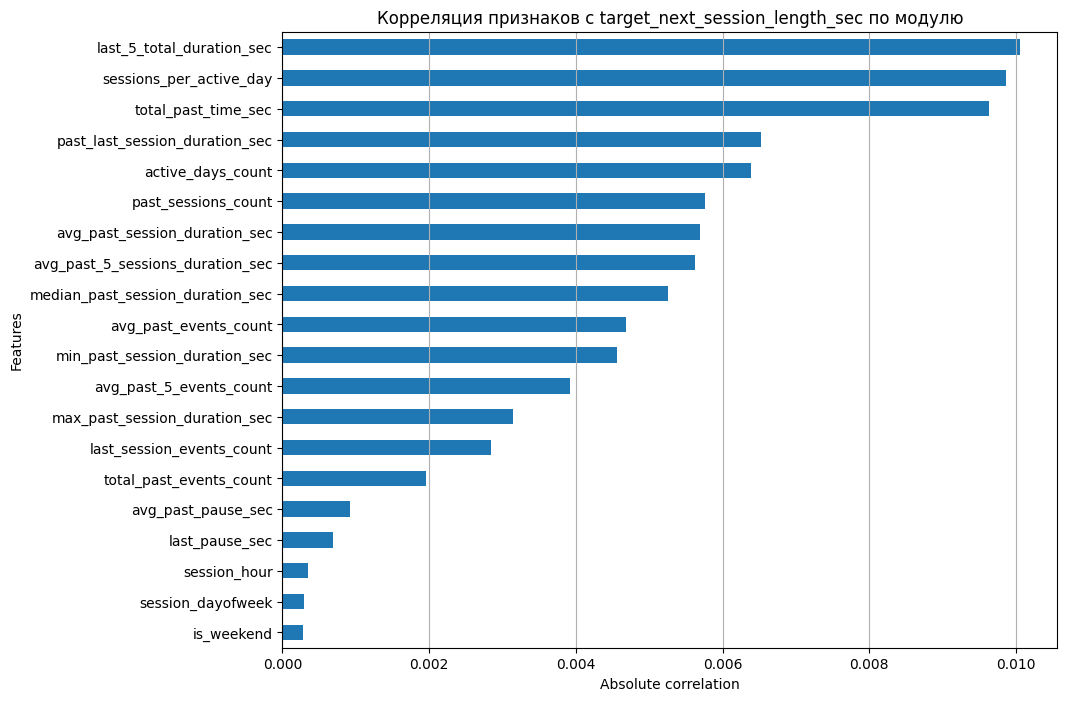

In [41]:
target_corr = corr["target_next_session_length_sec"].drop("target_next_session_length_sec")

target_corr = target_corr.abs().sort_values()

plt.figure(figsize=(10, 8))
target_corr.plot(kind="barh")
plt.title("Корреляция признаков с target_next_session_length_sec по модулю")
plt.xlabel("Absolute correlation")
plt.ylabel("Features")
plt.grid(axis="x")
plt.show()

У всех созданных признаков связь с целевой переменной достаточно слабая, те длина следующей сессии плохо объясняется только одним отдельным признаком линейно. 

5 признаков с наименьшей корреляцией пока не удаляю, так как корреляция показывает только линейную связь. last_pause_sec, avg_past_pause_sec, session_hour, session_dayofweek, is_weekend могут быть полезны для нелинейных моделей и бизнес-интерпретации, особенно для анализа удержания и времени активности пользователей.

In [42]:
top_5_features = target_corr.sort_values(ascending=False).head(5)
weak_5_features = target_corr.sort_values(ascending=True).head(5)

print("Топ-5 признаков по корреляции:")
display(top_5_features)
print()
print("5 признаков с наименьшей корреляцией:")
display(weak_5_features)

Топ-5 признаков по корреляции:


last_5_total_duration_sec         0.010060
sessions_per_active_day           0.009867
total_past_time_sec               0.009624
past_last_session_duration_sec    0.006528
active_days_count                 0.006389
Name: target_next_session_length_sec, dtype: float64


5 признаков с наименьшей корреляцией:


is_weekend            0.000282
session_dayofweek     0.000293
session_hour          0.000353
last_pause_sec        0.000686
avg_past_pause_sec    0.000924
Name: target_next_session_length_sec, dtype: float64

In [43]:
sessions_eda["target_next_session_length_sec"].describe()

count    3.666584e+06
mean     1.056957e+03
std      3.646091e+04
min      0.000000e+00
25%      6.500000e+01
50%      2.750000e+02
75%      7.840000e+02
max      1.250430e+07
Name: target_next_session_length_sec, dtype: float64

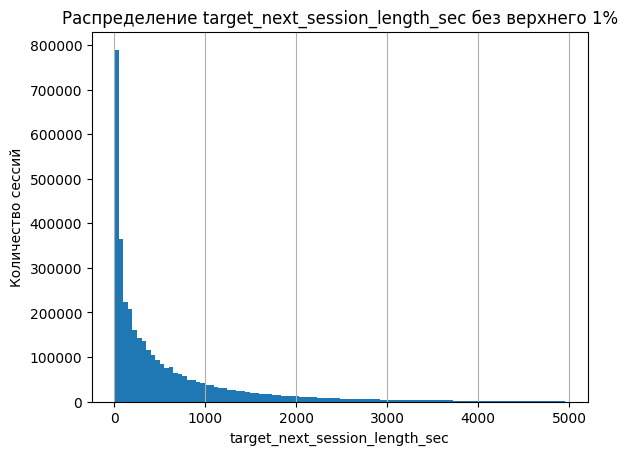

In [44]:
q99 = sessions_eda["target_next_session_length_sec"].quantile(0.99)

sessions_eda[sessions_eda["target_next_session_length_sec"] <= q99]["target_next_session_length_sec"].hist(bins=100)

plt.title("Распределение target_next_session_length_sec без верхнего 1%")
plt.xlabel("target_next_session_length_sec")
plt.ylabel("Количество сессий")
plt.grid(axis="y")
plt.show()

<Axes: >

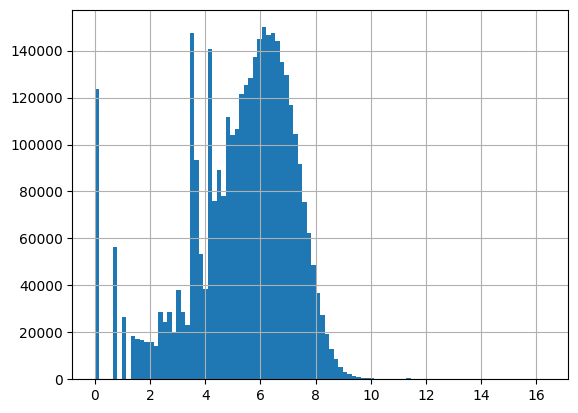

In [45]:
np.log1p(sessions_eda["target_next_session_length_sec"]).hist(bins=100)

Медианная длина следующей сессии составляет около 275 секунд, а среднее значение - около 1057 секунд. Среднее значительно больше медианы, значит распределение скошено вправо: большинство следующих сессий короткие, но есть маленькое количество супер длинных сессий.

Минимальное значение таргета равно 0, то есть в данных есть сессии с нулевой длительностью следующей сессии. Максимальное значение достигает примерно 12.5 млн секунд, скорее всего выброс. Исходное распределение таргета имеет выраженный правый хвост. После логирования таргета log1p. распределение становится более адекватным: основная масса значений находится в центральной области, а влияние экстремально длинных сессий уменьшается. <span style="color:red">В будущем надо будет обработать выбросы и залогарифмировать таргет перед обучением.</span>

Посмотрим пропуски по таргету

In [46]:
sessions["target_next_session_length_sec"].isna().mean()

np.float64(0.11730020662863108)

Доля пропусков в target_next_session_length_sec составляет около 11.7%. Эти пропуски появляются у последних сессий пользователей, потому что для них неизвестна следующая сессия, а значит невозможно посчитать длительность следующей сессии. Такие строчки удаляем, тк по ним нельзя сравнить прогноз с реальным значением

In [47]:
sessions_eda = sessions.dropna(subset=["target_next_session_length_sec"]).copy()

print(sessions.shape)
print(sessions_eda.shape)

(4153829, 32)
(3666584, 32)


Обработаем пропуски

In [48]:
sessions[feature_cols].isna().mean().sort_values(ascending=False)

avg_past_pause_sec                  0.182618
past_last_session_duration_sec      0.117300
avg_past_5_sessions_duration_sec    0.117300
avg_past_session_duration_sec       0.117300
last_session_events_count           0.117300
median_past_session_duration_sec    0.117300
max_past_session_duration_sec       0.117300
total_past_time_sec                 0.117300
min_past_session_duration_sec       0.117300
last_5_total_duration_sec           0.117300
last_pause_sec                      0.117300
sessions_per_active_day             0.117300
avg_past_5_events_count             0.117300
avg_past_events_count               0.117300
past_sessions_count                 0.000000
active_days_count                   0.000000
total_past_events_count             0.000000
session_hour                        0.000000
session_dayofweek                   0.000000
is_weekend                          0.000000
dtype: float64

In [49]:
session_base_cols = [
    "past_sessions_count",
    "active_days_count",
    "session_hour",
    "session_dayofweek",
    "is_weekend"
]

sessions[session_base_cols].isna().mean().sort_values(ascending=False)

past_sessions_count    0.0
active_days_count      0.0
session_hour           0.0
session_dayofweek      0.0
is_weekend             0.0
dtype: float64

Все чисто, пропусков нет

In [50]:
second_feature_cols = [
    "past_last_session_duration_sec",
    "avg_past_session_duration_sec",
    "avg_past_5_sessions_duration_sec",
    "median_past_session_duration_sec",
    "total_past_time_sec",
    "max_past_session_duration_sec",
    "min_past_session_duration_sec",
    "last_5_total_duration_sec",
    "last_pause_sec",
    "avg_past_pause_sec",
    "sessions_per_active_day",
    "avg_past_events_count",
    "last_session_events_count",
    "avg_past_5_events_count"
]

sessions[second_feature_cols].isna().mean().sort_values(ascending=False)

avg_past_pause_sec                  0.182618
past_last_session_duration_sec      0.117300
avg_past_5_sessions_duration_sec    0.117300
median_past_session_duration_sec    0.117300
total_past_time_sec                 0.117300
avg_past_session_duration_sec       0.117300
max_past_session_duration_sec       0.117300
min_past_session_duration_sec       0.117300
last_5_total_duration_sec           0.117300
last_pause_sec                      0.117300
sessions_per_active_day             0.117300
avg_past_events_count               0.117300
last_session_events_count           0.117300
avg_past_5_events_count             0.117300
dtype: float64

У всех есть пропуски и их довольно много

Обработаем их

In [51]:
for i in second_feature_cols:
    sessions[i + "_is_missing"] = sessions[col].isna().astype(int)
    sessions[i] = sessions[col].fillna(0)

sessions[second_feature_cols].isna().mean().sort_values(ascending=False)

past_last_session_duration_sec      0.0
avg_past_session_duration_sec       0.0
avg_past_5_sessions_duration_sec    0.0
median_past_session_duration_sec    0.0
total_past_time_sec                 0.0
max_past_session_duration_sec       0.0
min_past_session_duration_sec       0.0
last_5_total_duration_sec           0.0
last_pause_sec                      0.0
avg_past_pause_sec                  0.0
sessions_per_active_day             0.0
avg_past_events_count               0.0
last_session_events_count           0.0
avg_past_5_events_count             0.0
dtype: float64

In [52]:
sessions[feature_cols].isna().mean().sort_values(ascending=False).head(20)

past_sessions_count                 0.0
past_last_session_duration_sec      0.0
avg_past_session_duration_sec       0.0
avg_past_5_sessions_duration_sec    0.0
median_past_session_duration_sec    0.0
total_past_time_sec                 0.0
max_past_session_duration_sec       0.0
min_past_session_duration_sec       0.0
last_5_total_duration_sec           0.0
last_pause_sec                      0.0
avg_past_pause_sec                  0.0
active_days_count                   0.0
sessions_per_active_day             0.0
total_past_events_count             0.0
avg_past_events_count               0.0
last_session_events_count           0.0
avg_past_5_events_count             0.0
session_hour                        0.0
session_dayofweek                   0.0
is_weekend                          0.0
dtype: float64

In [53]:
sessions.to_csv("/kaggle/working/sessions_with_session_features_final_1.csv", index=False)

In [54]:
from IPython.display import FileLink

FileLink("/kaggle/working/sessions_with_session_features_final.csv")

/kaggle/working/sessions_with_session_features_final.csv

In [55]:
import shutil
from IPython.display import FileLink

shutil.make_archive(
    "/kaggle/working/sessions_with_session_features_final",
    "zip",
    "/kaggle/working",
    "sessions_with_session_features_final.csv"
)

FileLink("/kaggle/working/sessions_with_session_features_final.zip")

/kaggle/working/sessions_with_session_features_final.zip

In [ ]:
sessions.to_parquet("/kaggle/working/sessions_with_session_features_final.parquet", index=False)